In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [35]:
df = pd.read_csv('Cardiovascular_Disease.csv')

In [37]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [39]:
df = df[(df['ap_hi']> 80) & (df['ap_hi']<200)]
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [41]:
df['age_years'] = df['age']/365


In [43]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.391781
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.419178
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.663014
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.282192
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.873973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52.712329
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61.920548
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52.235616
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61.454795


In [45]:
df_sample = df.sample(n=1000, random_state=42)
df_sample

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
49790,71085,19976,1,162,91.0,120,80,2,1,0,0,1,0,54.728767
23006,32869,19744,1,169,95.0,130,80,1,1,0,1,1,0,54.093151
31139,44455,20418,1,161,77.0,120,70,1,1,0,0,1,1,55.939726
8075,11518,21939,2,165,78.0,140,90,1,1,0,0,1,1,60.106849
43511,62162,17528,2,172,86.0,120,80,1,1,0,0,1,0,48.021918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68711,98165,21967,2,166,55.0,140,80,1,1,1,1,1,1,60.183562
12273,17524,18290,1,153,74.0,130,90,1,1,0,0,1,0,50.109589
47247,67494,20561,1,170,85.0,130,80,1,1,0,0,0,1,56.331507
443,631,17423,1,162,84.0,110,90,1,1,0,0,1,1,47.734247


In [130]:
features = ['age_years','ap_hi']
target = 'cardio'


In [132]:
X = df_sample[features]
Y = df_sample[target]


In [134]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size = 0.2 ,random_state = 42, stratify = Y
)

In [136]:
df_sample['ap_hi'].unique()

array([120, 130, 140, 110, 150,  90, 180, 171, 100, 160, 115, 170, 125,
       141, 133, 142, 145, 118, 151, 138, 190, 135, 105, 155, 162, 128],
      dtype=int64)

In [138]:
scaler = StandardScaler()

In [140]:
X_train_scale = scaler.fit_transform(X_train)

In [141]:
X_test_scale = scaler.transform(X_test)

In [144]:
model = SVC(kernel = 'rbf' ,C = 1.0,gamma ='scale')

In [146]:
model.fit(X_train_scale,Y_train)

SVC()

In [148]:
Y_pred = model.predict(X_test_scale)

In [150]:
cm = confusion_matrix(Y_test,Y_pred)

In [152]:
cm

array([[75, 25],
       [28, 72]], dtype=int64)

In [154]:
cr = classification_report(Y_test,Y_pred) 

<Axes: >

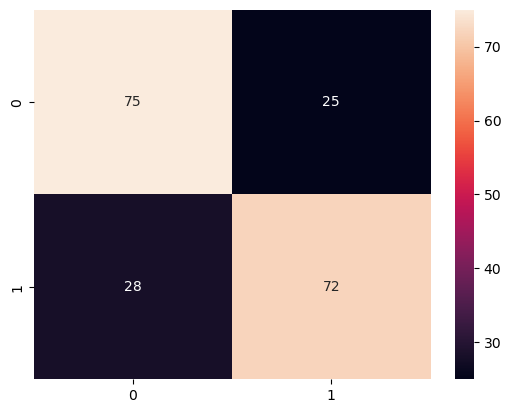

In [156]:
sns.heatmap(cm , annot = True)

In [177]:
#line size
h = .02


In [179]:
x_min , x_max = X_train_scale[:,0].min()-1,X_train_scale[:,0].max()+1
y_min ,y_max = X_train_scale[:,1].min()-1,X_train_scale[:,1].max()+1

In [181]:
xx ,yy = np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))

In [183]:
z = model.predict(np.c_[xx.ravel(),yy.ravel()])
z = z.reshape(xx.shape)

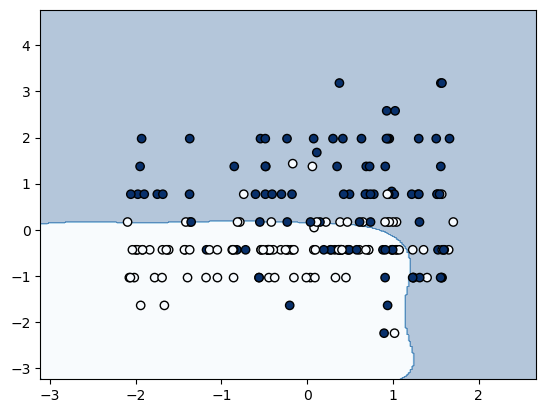

In [184]:
plt.contourf(xx,yy,z,cmap = 'Blues' , alpha = 0.3)
plt.scatter(X_test_scale[:,0] ,X_test_scale[:,1], c=Y_test , cmap = 'Blues', edgecolor = 'k')